In [ ]:
!pip install torchvision matplotlib --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.0 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataloader = DataLoader(
    datasets.MNIST(root='./data', train=True, download=True, transform=transform),
    batch_size=128,
    shuffle=True
)
# Generator: Upsampling from noise to 28x28 using ConvTranspose2d
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(100, 128, kernel_size=7, stride=1, padding=0),  # 7x7
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 14x14
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),   # 28x28
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


# Discriminator: CNN to classify 28x28 as real or fake
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),  # 14x14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 7x7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128*7*7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
g_optimizer = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

fixed_noise = torch.randn(1, 100, 1, 1).to(device)  # Same noise vector for tracking evolution


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.87MB/s]


Epoch [1/30]  D Loss: 0.5812  G Loss: 2.6128
Epoch [2/30]  D Loss: 0.4471  G Loss: 1.6400
Epoch [3/30]  D Loss: 0.9382  G Loss: 1.7233
Epoch [4/30]  D Loss: 0.4054  G Loss: 1.9541
Epoch [5/30]  D Loss: 0.4481  G Loss: 1.5578


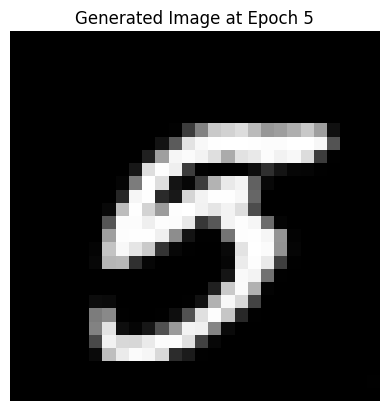

Epoch [6/30]  D Loss: 0.6341  G Loss: 2.2952
Epoch [7/30]  D Loss: 0.7136  G Loss: 1.4735
Epoch [8/30]  D Loss: 0.3696  G Loss: 2.5017
Epoch [9/30]  D Loss: 0.6171  G Loss: 2.5939
Epoch [10/30]  D Loss: 0.5827  G Loss: 3.4613


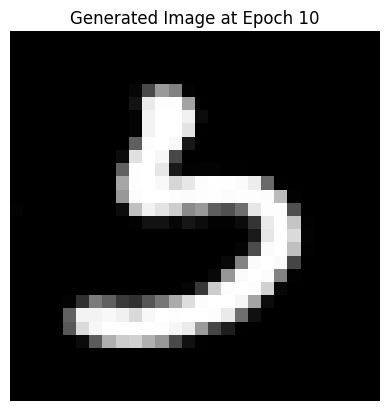

Epoch [11/30]  D Loss: 0.4867  G Loss: 2.0008
Epoch [12/30]  D Loss: 0.5194  G Loss: 3.0156
Epoch [13/30]  D Loss: 0.3959  G Loss: 3.5650
Epoch [14/30]  D Loss: 0.4991  G Loss: 2.5622
Epoch [15/30]  D Loss: 0.5825  G Loss: 1.9019


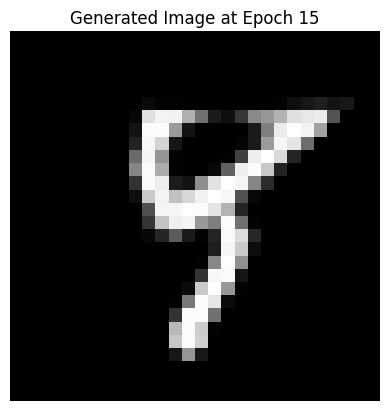

Epoch [16/30]  D Loss: 0.4626  G Loss: 2.5717
Epoch [17/30]  D Loss: 0.4123  G Loss: 2.0936
Epoch [18/30]  D Loss: 0.4886  G Loss: 2.5140
Epoch [19/30]  D Loss: 0.4883  G Loss: 1.3802
Epoch [20/30]  D Loss: 0.4200  G Loss: 1.9146


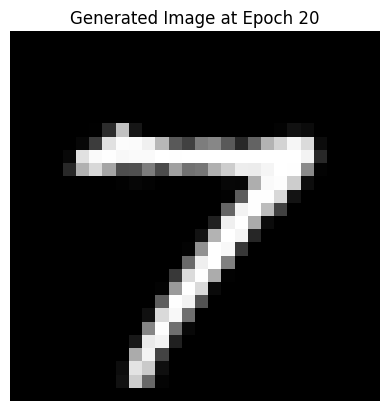

Epoch [21/30]  D Loss: 0.7395  G Loss: 1.1468
Epoch [22/30]  D Loss: 0.5062  G Loss: 3.6781
Epoch [23/30]  D Loss: 0.8857  G Loss: 3.9931
Epoch [24/30]  D Loss: 0.4397  G Loss: 1.9565
Epoch [25/30]  D Loss: 0.5048  G Loss: 3.1428


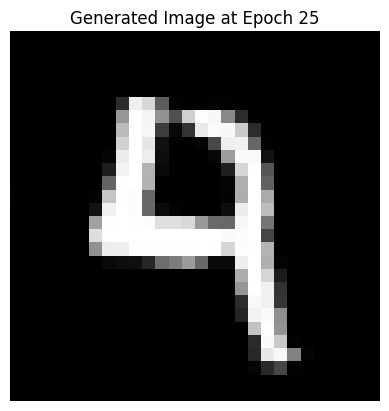

Epoch [26/30]  D Loss: 0.5305  G Loss: 1.6042
Epoch [27/30]  D Loss: 0.5638  G Loss: 1.7901
Epoch [28/30]  D Loss: 0.3657  G Loss: 3.0187
Epoch [29/30]  D Loss: 0.6264  G Loss: 3.8067
Epoch [30/30]  D Loss: 0.3096  G Loss: 3.4376


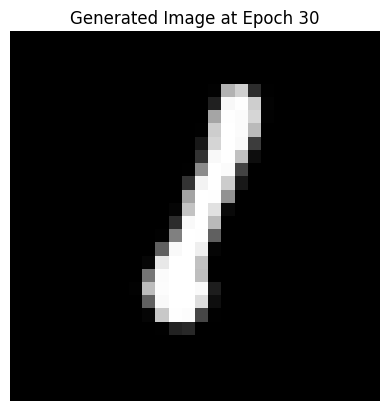

In [ ]:
epochs = 30

for epoch in range(epochs):
    for real_images, _ in dataloader:
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator
        z = torch.randn(batch_size, 100, 1, 1).to(device)
        fake_images = G(z)

        real_outputs = D(real_images)
        fake_outputs = D(fake_images.detach())

        d_loss = criterion(real_outputs, real_labels) + criterion(fake_outputs, fake_labels)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        z = torch.randn(batch_size, 100, 1, 1).to(device)
        fake_images = G(z)
        outputs = D(fake_images)

        g_loss = criterion(outputs, real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}]  D Loss: {d_loss.item():.4f}  G Loss: {g_loss.item():.4f}")

    # Generate image every 5 epochs
    if (epoch + 1) % 5 == 0:
        G.eval()
        with torch.no_grad():
          z = torch.randn(1, 100, 1, 1).to(device)  # Random noise
          gen_img = G(z).cpu().squeeze()
        plt.imshow(gen_img, cmap='gray')
        plt.title(f'Generated Image at Epoch {epoch+1}')
        plt.axis('off')
        plt.show()
        G.train()
